##### 1. Import Libraries

In [71]:
import pandas as pd
import numpy as np
from scipy.stats import zscore
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from scipy.stats.mstats import winsorize

# Part A: Handling Missing Values

In [5]:
data = pd.read_csv('Patient_Health_Records_Dataset.csv')
display(data.head())
print(data.isna().sum())

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,32.0,Male,NaN,NaN,102.6,136.4,151.5,1
1,2,71.0,Male,West,28.2,162.8,121.0,158.6,1
2,3,76.0,Male,West,18.5,116.4,220.6,167.4,1
3,4,NaN,Male,East,23.8,150.3,232.3,145.2,1
4,5,25.0,Male,North,32.3,126.1,130.6,170.4,1


patient_id         0
age               42
gender            22
region            23
bmi               47
blood_pressure     0
cholesterol       42
glucose           34
disease_risk       0
dtype: int64


In [7]:
missing = pd.DataFrame({
    "Missing Values": data.isnull().sum(),
    "Percentage": (data.isnull().sum()/len(data))*100
})

missing

,Missing Values,Percentage
patient_id,0,0.0
age,42,8.4
gender,22,4.4
region,23,4.6
bmi,47,9.4
blood_pressure,0,0.0
cholesterol,42,8.4
glucose,34,6.8
disease_risk,0,0.0


##### 1) Simple Imputer (Numerical)

In [35]:
mean_Imputer = SimpleImputer(strategy='mean')
data['bmi'] = mean_Imputer.fit_transform(data[['bmi']])
print(data['bmi'].isna().sum())

0


##### 2) Simple Imputer (Categorical)

In [36]:
most_frequent_Imputer = SimpleImputer(strategy = 'most_frequent')
data['region']=  most_frequent_Imputer.fit_transform(data[['region']]).flatten()
print(data['region'].isnull().sum())

0


In [37]:
most_frequent_Imputer = SimpleImputer(strategy = 'most_frequent')
data['gender']=  most_frequent_Imputer.fit_transform(data[['gender']]).flatten()
print(data['gender'].isnull().sum())

0


##### 3) Missing Indicator + Random Sample Imputation

In [38]:
data["age_missing"] = data["age"].isnull().astype(int)

In [39]:
random_sample = data["age"].dropna().sample(
    data["age"].isnull().sum(),
    random_state=42,
    replace=True
)

data.loc[data["age"].isnull(), "age"] = random_sample.values
print(data['age'].isnull().sum())

0


##### 5) KNN Imputer

In [40]:
cols = [
    "age",
    "bmi",
    "blood_pressure",
    "cholesterol",
    "glucose"
]

knn = KNNImputer(n_neighbors=5)

data[cols] = knn.fit_transform(data[cols])
data[cols].isnull().sum()

age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
dtype: int64

##### 6) MICE Algorithm

In [41]:
cols = [
    "age",
    "bmi",
    "blood_pressure",
    "cholesterol",
    "glucose"
]

mice = IterativeImputer(random_state=42)

data[cols] = mice.fit_transform(data[cols])
data[cols].isnull().sum()

age               0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
dtype: int64

##### Checking the final dataset after handling missing values

In [43]:
display(data.head())
print(data.isna().sum())

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing
0,1,32.0,Male,West,26.685651,102.6,136.4,151.5,1,0
1,2,71.0,Male,West,28.200000,162.8,121.0,158.6,1,0
2,3,76.0,Male,West,18.500000,116.4,220.6,167.4,1,0
3,4,83.0,Male,East,23.800000,150.3,232.3,145.2,1,0
4,5,25.0,Male,North,32.300000,126.1,130.6,170.4,1,0


patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
age_missing       0
dtype: int64


- Conclusion

1. Mean and Median imputation are simple and fast.
2. Most Frequent imputation is suitable for categorical variables.
3. Random Sample Imputation preserves the data distribution.
4. KNN uses neighboring samples to estimate missing values.
5. MICE provides more accurate multivariate imputation by modeling relationships among variables.

# Part B: Handling Outliers

Before Shape: (500, 10)


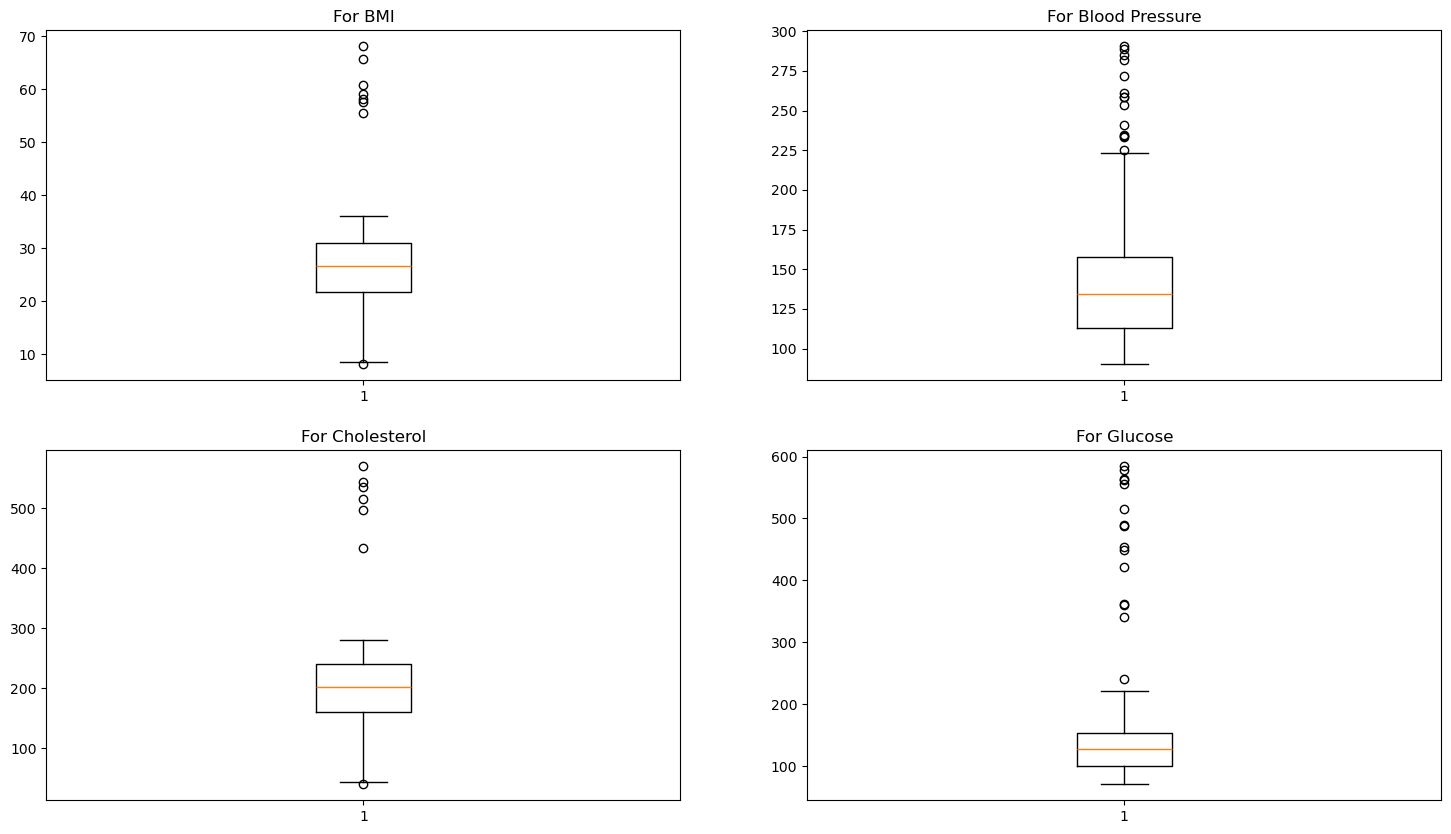

In [58]:
print("Before Shape:", data.shape)
columns = ["bmi","blood_pressure","cholesterol","glucose"]

plt.figure(figsize=(18,10))
plt.subplot(2,2,1)
plt.title("For BMI")
plt.boxplot(data["bmi"])
plt.subplot(2,2,2)
plt.title("For Blood Pressure")
plt.boxplot(data["blood_pressure"])
plt.subplot(2,2,3)
plt.title("For Cholesterol")
plt.boxplot(data["cholesterol"])
plt.subplot(2,2,4)
plt.title("For Glucose")
plt.boxplot(data["glucose"])
plt.show()

##### 1) Z-Score Method

In [66]:
data["z_score"] = zscore(data['cholesterol'], nan_policy="omit")

print("\nZ-Score")
print(data[["patient_id", "cholesterol", "z_score"]])

outliers = data[data["z_score"].abs() > 3]

print("\nOutliers")
print(outliers[["patient_id", "cholesterol", "z_score"]])

df_clean = data[data["z_score"].abs() <= 3].copy()

df_clean.drop(columns=["z_score"], inplace=True)

print("\nRows Before :", len(data))
print("Rows After  :", len(df_clean))
print("Outliers Removed :", len(data) - len(df_clean))

print("\nMean Before :", data["cholesterol"].mean())
print("Mean After  :", df_clean["cholesterol"].mean())


Z-Score
     patient_id  cholesterol   z_score
0             1       136.40 -1.279086
1             2       121.00 -1.592670
2             3       220.60  0.435447
3             4       232.30  0.673689
4             5       130.60 -1.397189
..          ...          ...       ...
495         496       222.90  0.482281
496         497       155.60 -0.888123
497         498       182.30 -0.344442
498         499       179.20 -0.407566
499         500       211.58  0.251776

[494 rows x 3 columns]

Outliers
     patient_id  cholesterol   z_score
30           31         44.6 -3.148374
197         198         40.1 -3.240006
252         253         43.6 -3.168737

Rows Before : 494
Rows After  : 491
Outliers Removed : 3

Mean Before : 199.21538461538464
Mean After  : 200.17128309572303


##### 2) IQR Method

In [69]:
Q1 = data["bmi"].quantile(0.25)
Q3 = data["bmi"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - (1.5 * IQR)
upper_limit = Q3 + (1.5 * IQR)

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

print("Lower Limit :", lower_limit)
print("Upper Limit :", upper_limit)

outliers = data[
    (data["bmi"] < lower_limit) |
    (data["bmi"] > upper_limit)
]

print("\nOutliers")
print(outliers[["patient_id", "bmi"]])

df_clean = data[
    (data["bmi"] >= lower_limit) &
    (data["bmi"] <= upper_limit)
]

print("\nRows Before :", len(data))
print("Rows After :", len(df_clean))
print("Outliers Removed :", len(data) - len(df_clean))

print("\nMean Before :", data["bmi"].mean())
print("Mean After :", df_clean["bmi"].mean())

Q1 : 21.8
Q3 : 30.9
IQR : 9.099999999999998
Lower Limit : 8.150000000000004
Upper Limit : 44.55

Outliers
     patient_id   bmi
56           57  59.1
126         127  55.5
258         259  58.2
263         264  65.7
314         315  68.1
387         388  57.6
460         461   8.1
490         491  60.7

Rows Before : 494
Rows After : 486
Outliers Removed : 8

Mean Before : 26.72521114298737
Mean After : 26.27418581200774


##### 3) Percentile Method

In [70]:
from pyparsing import col


lower_limit = data['blood_pressure'].quantile(0.01)
upper_limit = data['blood_pressure'].quantile(0.99)

print("1st Percentile :", lower_limit)
print("99th Percentile :", upper_limit)

outliers = data[
    (data['blood_pressure'] < lower_limit) |
    (data['blood_pressure'] > upper_limit)
]

print("\nOutliers")
print(outliers[["patient_id", "blood_pressure"]])

df_clean = data[
    (data['blood_pressure'] >= lower_limit) &
    (data['blood_pressure'] <= upper_limit)
]

print("\nRows Before :", len(data))
print("Rows After :", len(df_clean))
print("Outliers Removed :", len(data)-len(df_clean))

print("\nMean Before :", data['blood_pressure'].mean())
print("Mean After :", df_clean['blood_pressure'].mean())


1st Percentile : 91.479
99th Percentile : 261.85599999999994

Outliers
     patient_id  blood_pressure
23           24            90.0
52           53            90.8
60           61           288.7
126         127           285.1
274         275           282.2
292         293           290.6
311         312           271.9
320         321            91.0
359         360            90.9
400         401            91.2

Rows Before : 494
Rows After : 484
Outliers Removed : 10

Mean Before : 137.7431174089069
Mean After : 136.72045454545454


##### 5) Winsorization

In [72]:
data["winsorized"] = winsorize(data['blood_pressure'], limits=[0.01,0.01])

print(data[['blood_pressure','winsorized']].head())

print("\nOriginal Mean :", data['blood_pressure'].mean())
print("Winsorized Mean :", data['winsorized'].mean())

   blood_pressure  winsorized
0           102.6       102.6
1           162.8       162.8
2           116.4       116.4
3           150.3       150.3
4           126.1       126.1

Original Mean : 137.7431174089069
Winsorized Mean : 137.62793522267208


##### Conclusion

In [74]:
print("Original Dataset")
print(data.describe())

print("\nZ-Score Dataset")
print(data.describe())

print("\nIQR Dataset")
print(data.describe())

print("\nPercentile Dataset")
print(data.describe())

print("\nWinsorization Dataset")
print(data.describe())

Original Dataset
       patient_id         age         bmi  blood_pressure  cholesterol  \
count  494.000000  494.000000  494.000000      494.000000   494.000000   
mean   249.117409   51.943320   26.725211      137.743117   199.215385   
std    144.456168   19.363629    6.760223       32.878872    49.159379   
min      1.000000   18.000000    8.100000       90.000000    40.100000   
25%    124.250000   36.000000   21.800000      113.225000   160.550000   
50%    248.500000   52.000000   26.685651      134.250000   201.760000   
75%    373.750000   68.000000   30.900000      157.675000   238.225000   
max    500.000000   85.000000   68.100000      290.600000   279.800000   

          glucose  disease_risk  age_missing       z_score  winsorized  
count  494.000000    494.000000        494.0  4.940000e+02  494.000000  
mean   135.869798      0.829960          0.0 -4.261099e-16  137.627935  
std     68.149573      0.376049          0.0  1.001014e+00   32.351907  
min     71.000000      0

c:\Users\Priyansh\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Priyansh\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Priyansh\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Priyansh\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Priyansh\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\Users\Priyansh\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask'

# Part C: Final Cleaned Dataset

In [76]:
data["bmi"] = data["bmi"].clip(
    lower=data["bmi"].quantile(0.01),
    upper=data["bmi"].quantile(0.99)
)

data["blood_pressure"] = data["blood_pressure"].clip(
    lower=data["blood_pressure"].quantile(0.01),
    upper=data["blood_pressure"].quantile(0.99)
)

data["cholesterol"] = data["cholesterol"].clip(
    lower=data["cholesterol"].quantile(0.01),
    upper=data["cholesterol"].quantile(0.99)
)

data["glucose"] = data["glucose"].clip(
    lower=data["glucose"].quantile(0.01),
    upper=data["glucose"].quantile(0.99)
)

print("Final Clean Dataset")
display(data.head())

print("\nMissing Values")
print(data.isnull().sum())

Final Clean Dataset


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,age_missing,z_score,winsorized
0,1,32.0,Male,West,26.685651,102.6,136.4,151.5,1,0,-1.279086,102.6
1,2,71.0,Male,West,28.200000,162.8,121.0,158.6,1,0,-1.592670,162.8
2,3,76.0,Male,West,18.500000,116.4,220.6,167.4,1,0,0.435447,116.4
3,4,83.0,Male,East,23.800000,150.3,232.3,145.2,1,0,0.673689,150.3
4,5,25.0,Male,North,32.300000,126.1,130.6,170.4,1,0,-1.397189,126.1



Missing Values
patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
age_missing       0
z_score           0
winsorized        0
dtype: int64


### Brief Report

1. Which imputation strategy was most effective?

- The MICE (Multiple Imputation by Chained Equations) strategy was the most effective because it estimates missing values using the relationship between multiple features. It provides more accurate and reliable imputed values compared to simple mean, median, or most frequent imputation.

2. Which outlier handling method preserved data quality best?

- Winsorization preserved data quality best because it replaced extreme values with the nearest acceptable values instead of removing records. This reduced the effect of outliers while keeping the dataset size unchanged.

3. How did data cleaning improve dataset usability?

- Data cleaning removed missing values and treated outliers, making the dataset more accurate, consistent, and reliable. The cleaned dataset is now suitable for machine learning, statistical analysis, and predictive modeling.